In [ ]:
import logging

import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

logger = logging.getLogger('FIT PNG')

os.environ['OMPI_MCA_btl'] = 'self,tcp'  # deactivate shmem

# disable jax warning:
logging.getLogger("jax._src.xla_bridge").setLevel(logging.ERROR)
logging.getLogger("jax._src.distributed").setLevel(logging.ERROR)
# Remove warning from jax
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'


In [ ]:
import lsstypes
from clustering_statistics import setup_logging
 
from mpi4py import MPI
setup_logging(level=(logging.INFO if MPI.COMM_WORLD.rank == 0 else logging.ERROR))

from tools import read_data, rebin_data, get_observable_and_likelihood, run_profiler, run_mcmc, plot_triangle

# root = '/global/cfs/cdirs/desi/science/cai/desi-clustering/'
root = '/Users/edmond/Work/data/desi-clustering/' 

data_dir =  root + 'dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded'
mocks_dir = root + 'dr2/summary_statistics/local_png/base/'

logger.info(f'Load data from: {data_dir} and mocks from: {mocks_dir}')

[000000.00] [0/1] 05-27 16:58  FIT PNG                   INFO     Load data from: /Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/desi-data/loa-v1/v2/fNL/blinded and mocks from: /Users/edmond/Work/data/desi-clustering/dr2/summary_statistics/local_png/base/


In [4]:
def propose_fiducial():
    propose_fiducial = {}

    propose_fiducial['LRG'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.4, 1.1), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmax': 0.08, 'kmax_ell2': 0.08}
    
    propose_fiducial['QSO'] = {'weight_type': 'default-fkp-oqe', 'zrange': (0.8, 3.5), 'region': 'GCcomb', 
                               'use_ell2': True, 'kmax': 0.08, 'kmax_ell2': 0.08}

    return propose_fiducial

fiducial = propose_fiducial()

In [23]:
tracer = 'LRG' # 'QSO'
kmin = 3e-3

pk, window, _, mocks = read_data(data_dir=data_dir, mocks_dir=mocks_dir, tracer=tracer, 
                                 window_extra='', weight_type_mocks='default-fkp-oqe', **fiducial[tracer])
 
pk = lsstypes.mean(mocks[:50])

zeffs = {}
zeffs['LRGxLRG'] = {ell: window.observable.get(ell).attrs['zeff'] for ell in pk.ells}


chains = []
for kpivot, nrebin in zip([[1e-1], [1e-2, 2e-2], [2e-2], [1e-2, 2e-2]], [[1], [2,2], [4], [2, 4]]):
    logger.info(f'Running rebinning with kpivot={kpivot} and nrebin={nrebin}')

    pk_t, window_t, _, mocks_t = rebin_data(pk, window, None, mocks, tracer=tracer, kpivot=kpivot, nrebin=nrebin, kmin=kmin, kmin_ell2=kmin, **fiducial[tracer])
    try: 
        logger.info(f'After rebinning and k range selection: {pk_t.get(0).k.shape[0]} and {pk_t.get(2).k.shape[0]} data points.')
    except KeyError:
        logger.info(f'After rebinning and k range selection: {pk_t.get(0).k.shape[0]} data points.')

    observable, likelihood = get_observable_and_likelihood(pk_t, window_t, mocks_t, tracer, zeffs, engine='camb')
    profiler = run_profiler(likelihood)
    sampler = run_mcmc(likelihood, max_iterations=20000, check_every=20000)

    from desilike.samples import Chain
    burnin, thin = 0.2, 50

    chains.append(Chain.concatenate([chain.remove_burnin(burnin)[::thin] for chain in sampler.chains]))
    #print(chains.to_stats(tablefmt="pretty"))

[005938.53] [0/1] 05-27 18:37  PNG fitting tools         INFO     Reading the window with window_extra=''
[005943.64] [0/1] 05-27 18:37  FIT PNG                   INFO     Running rebinning with kpivot=[0.1] and nrebin=[1]
[005944.11] [0/1] 05-27 18:37  FIT PNG                   INFO     After rebinning and k range selection: 77 and 37 data points.
[005944.11] [0/1] 05-27 18:37  PNG fitting tools         INFO     tracers_theo=['LRG_ell0'], ell=0, zeff=0.8178
[005944.25] [0/1] 05-27 18:37  PNG fitting tools         INFO     tracers_theo=['LRG_ell2'], ell=2, zeff=0.814
[005944.34] [0/1] 05-27 18:37  PNG fitting tools         INFO     Using mocks to estimate the covariance matrix.
[005944.88] [0/1] 05-27 18:37  ObservablesGaussianLikelihood INFO     Covariance matrix with 114 points built from 1000 observations.
[005944.88] [0/1] 05-27 18:37  ObservablesGaussianLikelihood INFO     ...resulting in a Hartlap 2007 factor of 0.8849.
[005946.44] [0/1] 05-27 18:37  ObservablesGaussianLikelihood

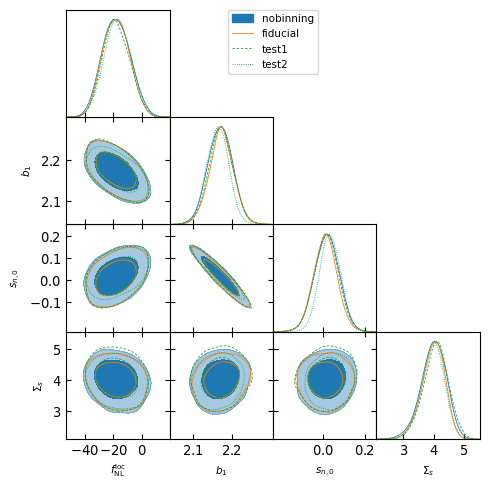

+-----------------+--------+-------+--------+-------+-----------------+-----------------+
|                 | argmax | mean  | median |  std  | quantile:1sigma | interval:1sigma |
+-----------------+--------+-------+--------+-------+-----------------+-----------------+
|     fnl_loc     | -18.5  | -17.8 | -18.0  |  9.8  |    -9.9/+9.9    |   -10.0/+9.8    |
|  LRG_ell0.sn0   | 0.019  | 0.020 | 0.020  | 0.058 |  -0.059/+0.058  |  -0.062/+0.054  |
|   LRG_ell0.b1   | 2.172  | 2.170 | 2.171  | 0.031 |  -0.031/+0.031  |  -0.031/+0.031  |
| LRG_ell0.sigmas |  4.03  | 4.00  |  4.02  | 0.42  |   -0.41/+0.42   |   -0.38/+0.44   |
|   LRG_ell2.b1   | 2.168  | 2.167 | 2.167  | 0.031 |  -0.031/+0.031  |  -0.031/+0.031  |
| LRG_ell2.sigmas |  4.03  | 4.00  |  4.02  | 0.42  |   -0.41/+0.42   |   -0.38/+0.44   |
+-----------------+--------+-------+--------+-------+-----------------+-----------------+
+-----------------+--------+-------+--------+-------+-----------------+-----------------+
|         

In [24]:
params = ['fnl_loc', 'LRG_ell0.b1', 'LRG_ell0.sn0', 'LRG_ell0.sigmas']
xlabels=[r'$f_{\rm NL}^{\rm loc}$', r'$b_1$', r'$s_{n,0}$', r'$\Sigma_s$']
plot_triangle(chains, params, legend_labels=['nobinning', 'fiducial', 'test1', 'test2'], xlabels=xlabels, 
            filled=True, contour_colors=['C0', 'C1', 'C2'], contour_ls=['-', '-', '--', ':'])

for cc in chains:
    print(cc.to_stats(tablefmt="pretty"))